# Experiment 2 — Treatment Policy Modelling

**Research question:** What morning-state features predict the training intensity assigned by the coaching staff?

This experiment models the **propensity / treatment-assignment policy** $\pi(A_t \mid L_t, \text{history})$, where:
- $A_t$ = today's training intensity (continuous $[0, 1)$, assigned **after** the morning assessment)
- $L_t$ = player's morning covariate state at time $t$ (fully observed **before** the session)

**Temporal alignment:** `target_variable = 'Training Intensity Yesterday'`, `target_horizon = 1`  
Row $t$'s features predict row $t+1$'s `Training Intensity Yesterday` = today's coaching assignment. Every predictor is from the morning of day $t$, which is the day **before** the assigned intensity becomes observable.

---

## Why model the treatment policy?
1. **Interpretability** — which signals most drive coaching load decisions?
2. **Propensity model** — $\hat{\pi}(A_t \mid L_t)$ is required for IPTW/MSM and doubly-robust estimators.
3. **Overlap diagnostics** — extreme propensity scores reveal insufficient variation in the prescribed intensities.

High predictability means the coaching policy is systematic; low predictability means unmeasured factors dominate. Either is scientifically informative.

---
## CONFIGURATION — edit this cell to change the experiment

All settings for this notebook are centralised here.

In [12]:
# ============================================================
#  EXPERIMENT 2 CONFIGURATION
# ============================================================

# --- Lag values to compare -------------------------------------------
LAGS = [1, 2, 3]

# --- Train / test / validation split ---------------------------------
TEST_SIZE = 0.2
VAL_SIZE  = 0.1

# --- Predictor columns -----------------------------------------------
# Only morning-assessment variables (available BEFORE the session).
# 'Training Intensity Yesterday' is the TARGET and must NOT appear here.
COVARIATES = [
    # Morning wellness
    'Fatigue (z)', 'Readiness (z)', 'Soreness (z)', 'Physical State',
    'Sleep Quality (z)', 'Stress (z)', 'Mood (z)', 'Mental State',
    'Overall Wellbeing',
    # Yesterday's load — ACWR ratios
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'Any ACWR Danger',
    # Yesterday's load — individual GPS benchmark %
    'Total Distance % Yesterday',
    'High Speed Distance % Yesterday',
    'High Decelerations % Yesterday',
    'Sprints % Yesterday',
    # Yesterday's raw GPS/HR
    'Total Minutes Yesterday',
    'Total Distance (m) Yesterday',
    'High Speed Distance (m) Yesterday',
    'Avg Heart Rate Yesterday',
    'Heart Rate Exertion Yesterday',
    # Temporal context
    'Days Since Game', 'Days Until Match',
    # Historical availability
    'Medical Availability Last 14 Days',
    'Club Attendance Last 14 Days',
    # Player profile and previous session type
    'Position', 'Activity Type Yesterday',
]

# --- Models to run ---------------------------------------------------
MODELS = ['lin_reg', 'xgboost', 'catboost', 'tabpfn']

# --- GPU overrides (passed to run_experiment as model_kwargs) --------
# These override the MODEL_DEFAULTS in scripts/Experiment2.py.
# Switch to 'cpu' / 'CPU' if no CUDA GPU is available.
GPU_OVERRIDES = {
    'xgboost':  {'device': 'cuda'},          # XGBoost >= 2.0
    'catboost': {'task_type': 'GPU'},         # CatBoost native CUDA
    'tabpfn':   {'device': 'cuda',           # TabPFN GPU inference
                 'ignore_pretraining_limits': True},  # bypass 1k-row CPU cap
}

# ============================================================
print(f"Lags to compare:  {LAGS}")
print(f"Models to run:    {MODELS}")
print(f"Covariates:       {len(COVARIATES)}")
print(f"Test / Val split: {TEST_SIZE} / {VAL_SIZE}")
print(f"GPU overrides:    {GPU_OVERRIDES}")

Lags to compare:  [1, 2, 3]
Models to run:    ['lin_reg', 'xgboost', 'catboost', 'tabpfn']
Covariates:       27
Test / Val split: 0.2 / 0.1
GPU overrides:    {'xgboost': {'device': 'cuda'}, 'catboost': {'task_type': 'GPU'}, 'tabpfn': {'device': 'cuda', 'ignore_pretraining_limits': True}}


## 0. Imports

In [13]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.extend([str(ROOT), str(ROOT / 'src'), str(ROOT / 'scripts')])

from Experiment2 import run_experiment

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Setup complete.")

Setup complete.


## 1. Run all models × all lags

Results are stored in `all_results[model_type][lag]`.

In [14]:
all_results = {m: {} for m in MODELS}

for model_type in MODELS:
    # Apply GPU overrides defined in the CONFIGURATION cell
    gpu_kwargs = GPU_OVERRIDES.get(model_type, {})
    for lag in LAGS:
        print(f"\n>>> {model_type}  lag={lag}  {gpu_kwargs or '(no GPU override)'}")
        all_results[model_type][lag] = run_experiment(
            covariates=COVARIATES,
            lag=lag,
            model_type=model_type,
            test_size=TEST_SIZE,
            val_size=VAL_SIZE,
            verbose=True,
            **gpu_kwargs,
        )

print("\nAll experiments complete.")


>>> lin_reg  lag=1  (no GPU override)
Experiment 2: Treatment Policy Modelling
Predict today's Training Intensity from morning covariates
  Target:      Training Intensity Yesterday  (target_horizon=1)
  Model:       lin_reg
  Lag:         1
  Covariates:  27
               . Fatigue (z)
               . Readiness (z)
               . Soreness (z)
               . Physical State
               . Sleep Quality (z)
               . Stress (z)
               . Mood (z)
               . Mental State
               . Overall Wellbeing
               . Total Distance (ACWR) Yesterday
               . High Speed Distance (ACWR) Yesterday
               . Any ACWR Danger
               . Total Distance % Yesterday
               . High Speed Distance % Yesterday
               . High Decelerations % Yesterday
               . Sprints % Yesterday
               . Total Minutes Yesterday
               . Total Distance (m) Yesterday
               . High Speed Distance (m) Yesterday
           

  Test  RMSE:  0.1577  (null: 0.2056)
  Train RMSE:  0.1101
  R2:          0.3935
  Pearson r:   0.6421  (p = 0.0000)
  MAE:         0.1253
  N test rows: 634  |  N train rows: 2359


>>> catboost  lag=2  {'task_type': 'GPU'}
Experiment 2: Treatment Policy Modelling
Predict today's Training Intensity from morning covariates
  Target:      Training Intensity Yesterday  (target_horizon=1)
  Model:       catboost
  Lag:         2
  Covariates:  27
               . Fatigue (z)
               . Readiness (z)
               . Soreness (z)
               . Physical State
               . Sleep Quality (z)
               . Stress (z)
               . Mood (z)
               . Mental State
               . Overall Wellbeing
               . Total Distance (ACWR) Yesterday
               . High Speed Distance (ACWR) Yesterday
               . Any ACWR Danger
               . Total Distance % Yesterday
               . High Speed Distance % Yesterday
               . High Decelerations % Yesterda

  Test  RMSE:  0.1583  (null: 0.2056)
  Train RMSE:  0.0828
  R2:          0.3885
  Pearson r:   0.6333  (p = 0.0000)
  MAE:         0.1247
  N test rows: 634  |  N train rows: 2359


>>> catboost  lag=3  {'task_type': 'GPU'}
Experiment 2: Treatment Policy Modelling
Predict today's Training Intensity from morning covariates
  Target:      Training Intensity Yesterday  (target_horizon=1)
  Model:       catboost
  Lag:         3
  Covariates:  27
               . Fatigue (z)
               . Readiness (z)
               . Soreness (z)
               . Physical State
               . Sleep Quality (z)
               . Stress (z)
               . Mood (z)
               . Mental State
               . Overall Wellbeing
               . Total Distance (ACWR) Yesterday
               . High Speed Distance (ACWR) Yesterday
               . Any ACWR Danger
               . Total Distance % Yesterday
               . High Speed Distance % Yesterday
               . High Decelerations % Yesterda

  Test  RMSE:  0.1618  (null: 0.2056)
  Train RMSE:  0.1137
  R2:          0.3611
  Pearson r:   0.6134  (p = 0.0000)
  MAE:         0.1281
  N test rows: 634  |  N train rows: 2359


>>> tabpfn  lag=1  {'device': 'cuda', 'ignore_pretraining_limits': True}
Experiment 2: Treatment Policy Modelling
Predict today's Training Intensity from morning covariates
  Target:      Training Intensity Yesterday  (target_horizon=1)
  Model:       tabpfn
  Lag:         1
  Covariates:  27
               . Fatigue (z)
               . Readiness (z)
               . Soreness (z)
               . Physical State
               . Sleep Quality (z)
               . Stress (z)
               . Mood (z)
               . Mental State
               . Overall Wellbeing
               . Total Distance (ACWR) Yesterday
               . High Speed Distance (ACWR) Yesterday
               . Any ACWR Danger
               . Total Distance % Yesterday
               . High Speed Distance % Yesterday
               . 

## 2. Comparison table (all models × all lags)

In [15]:
rows = []
for model_type in MODELS:
    for lag in LAGS:
        m = all_results[model_type][lag]['metrics']
        rows.append({
            'Model':       model_type,
            'Lag':         lag,
            'RMSE':        round(m['rmse'],       4),
            'Null RMSE':   round(m['null_rmse'],  4),
            'Skill (%)':   round((1 - m['rmse'] / m['null_rmse']) * 100, 1),
            'MAE':         round(m['mae'],        4),
            'R2':          round(m['r2'],         4),
            'Pearson r':   round(m['pearson_r'],  4),
            'Train RMSE':  round(m['train_rmse'], 4),
            'N test':      m['n_test'],
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

   Model  Lag   RMSE  Null RMSE  Skill (%)    MAE     R2  Pearson r  Train RMSE  N test
 lin_reg    1 0.1806     0.2056       12.2 0.1500 0.2042     0.4887      0.1968     634
 lin_reg    2 0.1821     0.2056       11.4 0.1530 0.1906     0.4741      0.1964     634
 lin_reg    3 0.1805     0.2056       12.2 0.1513 0.2048     0.4822      0.1949     634
 xgboost    1 0.1624     0.2056       21.0 0.1282 0.3566     0.6068      0.0917     634
 xgboost    2 0.1619     0.2056       21.3 0.1282 0.3609     0.6119      0.1078     634
 xgboost    3 0.1581     0.2056       23.1 0.1227 0.3901     0.6308      0.0883     634
catboost    1 0.1577     0.2056       23.3 0.1253 0.3935     0.6421      0.1101     634
catboost    2 0.1583     0.2056       23.0 0.1247 0.3885     0.6333      0.0828     634
catboost    3 0.1618     0.2056       21.3 0.1281 0.3611     0.6134      0.1137     634
  tabpfn    1 0.1505     0.2056       26.8 0.1157 0.4472     0.6711      0.0722     634
  tabpfn    2 0.1523     0.2056 

**Interpreting the table:**
- **Null RMSE** = always predict the training-set mean (dumbest baseline).
- **Skill (%)** = relative improvement over null: `(1 - RMSE/Null RMSE) × 100`.
- **Train RMSE vs RMSE**: gap indicates overfitting severity.
- **Lag effect**: if R² increases substantially with lag, historical load history matters beyond same-day state.

## 3. Visualisation — RMSE and R² across models and lags

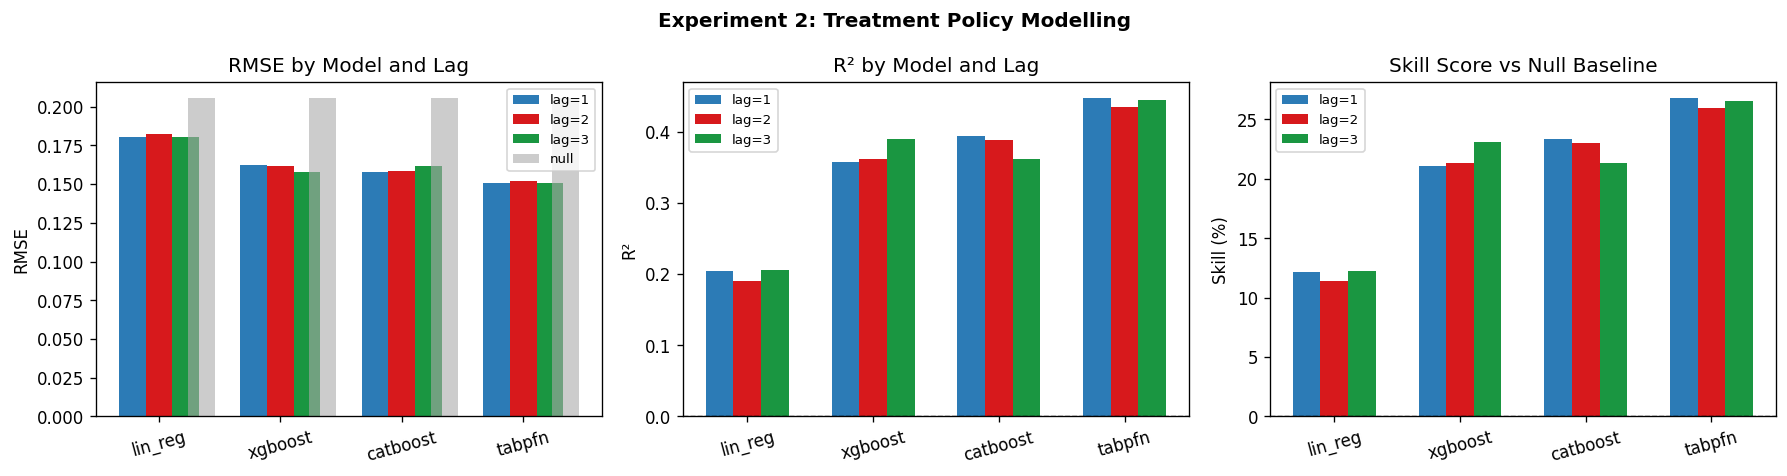

In [16]:
LAG_COLORS = {1: '#2c7bb6', 2: '#d7191c', 3: '#1a9641'}
x = np.arange(len(MODELS))
n_lags = len(LAGS)
w = 0.22

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- RMSE vs Null ---
ax = axes[0]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    rmses  = [all_results[m][lag]['metrics']['rmse']      for m in MODELS]
    ax.bar(x + offset, rmses, w, label=f'lag={lag}', color=LAG_COLORS[lag])
# null baseline (same for all lags of the same model — use lag=1)
nulls = [all_results[m][LAGS[0]]['metrics']['null_rmse'] for m in MODELS]
ax.bar(x + (n_lags / 2) * w + 0.02, nulls, w, label='null', color='#aaa', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('RMSE'); ax.set_title('RMSE by Model and Lag')
ax.legend(fontsize=8)

# --- R² ---
ax = axes[1]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    r2s = [all_results[m][lag]['metrics']['r2'] for m in MODELS]
    ax.bar(x + offset, r2s, w, label=f'lag={lag}', color=LAG_COLORS[lag])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('R²'); ax.set_title('R² by Model and Lag')
ax.legend(fontsize=8)

# --- Skill (%) ---
ax = axes[2]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    skills = [
        (1 - all_results[m][lag]['metrics']['rmse'] /
             all_results[m][lag]['metrics']['null_rmse']) * 100
        for m in MODELS
    ]
    ax.bar(x + offset, skills, w, label=f'lag={lag}', color=LAG_COLORS[lag])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('Skill (%)')
ax.set_title('Skill Score vs Null Baseline')
ax.legend(fontsize=8)

fig.suptitle('Experiment 2: Treatment Policy Modelling', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Lag effect — does more history help?

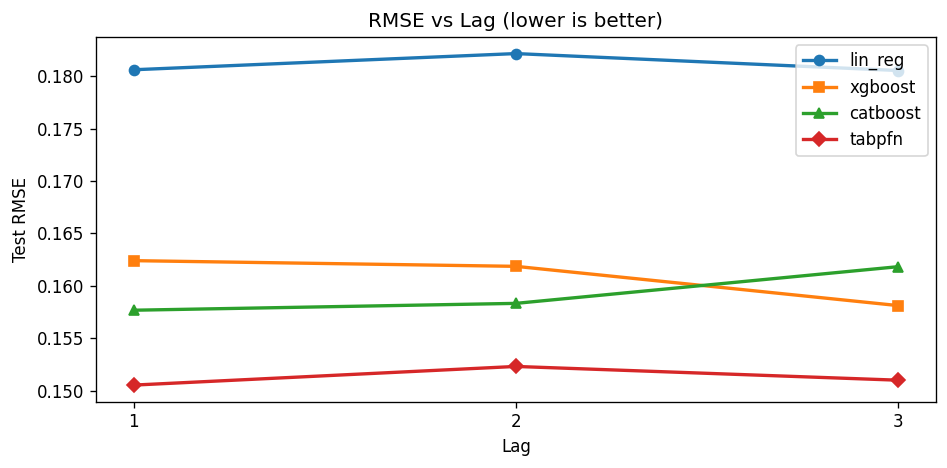

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
markers = ['o', 's', '^', 'D']
for j, model_type in enumerate(MODELS):
    rmses = [all_results[model_type][lag]['metrics']['rmse'] for lag in LAGS]
    ax.plot(LAGS, rmses, marker=markers[j % len(markers)],
            label=model_type, lw=2)

ax.set_xlabel('Lag'); ax.set_ylabel('Test RMSE')
ax.set_title('RMSE vs Lag (lower is better)')
ax.set_xticks(LAGS)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Best model — predicted vs actual and residuals

Best: tabpfn  lag=1  RMSE=0.1505  R2=0.4472


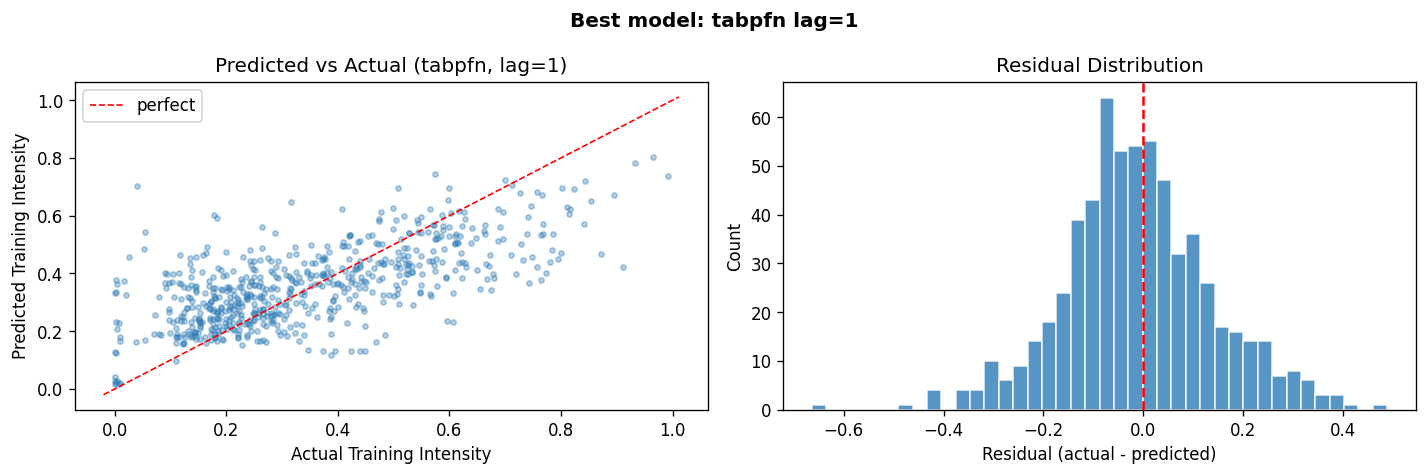

In [18]:
# Find the (model, lag) combination with lowest test RMSE
best = min(
    [(m, l) for m in MODELS for l in LAGS],
    key=lambda ml: all_results[ml[0]][ml[1]]['metrics']['rmse']
)
best_model, best_lag = best
res = all_results[best_model][best_lag]
print(f"Best: {best_model}  lag={best_lag}  "
      f"RMSE={res['metrics']['rmse']:.4f}  R2={res['metrics']['r2']:.4f}")

y_true = res['y_test_true']
y_pred = res['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.35, s=10, color='#2c7bb6')
lims = [min(y_true.min(), y_pred.min()) - 0.02,
        max(y_true.max(), y_pred.max()) + 0.02]
ax.plot(lims, lims, 'r--', lw=1, label='perfect')
ax.set_xlabel('Actual Training Intensity')
ax.set_ylabel('Predicted Training Intensity')
ax.set_title(f'Predicted vs Actual ({best_model}, lag={best_lag})')
ax.legend()

ax = axes[1]
residuals = y_true - y_pred
ax.hist(residuals, bins=40, color='#2c7bb6', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.suptitle(f'Best model: {best_model} lag={best_lag}', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature importances — best model

**What are feature importances?**

For tree-based models (XGBoost, CatBoost) the importance score reflects how much each feature contributes to reducing prediction error across all splits in all trees.  For the linear model (Ridge), importance is the absolute value of the coefficient (on standardised features, so magnitudes are comparable).

**Limitation of native importances:** they capture *how often* and *how much* a feature is used, but not the *direction* of its effect (higher fatigue → higher or lower intensity?) nor interactions between features.  Section 7 addresses this with SHAP.

In [19]:
weights = res.get('model_weights', {})
fnames  = res.get('feature_names', [])

imps = weights.get('importances') or weights.get('feature_importances')
if imps is None and 'coefficients' in weights:
    raw_coef = np.array(weights['coefficients']).flatten()
    imps = np.abs(raw_coef)

if imps is not None and len(fnames) > 0:
    imp_arr = np.array(imps).flatten()
    imp_df = pd.DataFrame({'feature': fnames, 'importance': imp_arr})
    imp_df = imp_df.sort_values('importance', ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#2c7bb6')
    ax.set_xlabel('Importance score')
    ax.set_title(f'Top-25 feature importances — {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()

    print("Top 10 features by importance:")
    print(imp_df.head(10).to_string(index=False))
else:
    print("No importances available for this model type.")

No importances available for this model type.


## 7. SHAP Analysis — explaining individual predictions

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into per-feature contributions, rooted in cooperative game theory.  Unlike native tree importances, SHAP shows both *magnitude* and *direction* of each feature's effect.

| Plot | What it reveals |
|------|-----------------|
| **Beeswarm** | Distribution of SHAP values across all test rows. Each dot = one prediction; colour = feature value (red=high, blue=low). Wide spread → large, variable effect. |
| **Bar** | Mean \|SHAP\| per feature — a clean global importance ranking comparable across model types. |
| **Dependence** | How the top feature's SHAP contribution changes with its raw value; interaction colour shows the most correlated secondary feature. |

> **Causal note:** SHAP values describe *predictive* contributions, not causal effects.  A feature with high SHAP importance may be a proxy for an unmeasured cause (e.g. `Days Until Match` proxies for periodisation-driven session planning).  Use these plots to understand *what the model learned*; use IPTW/G-computation (downstream causal analysis) for causal claims.

TabPFN is excluded — it is a black-box transformer and SHAP TreeExplainer is not applicable.

TabPFN detected -- using sklearn permutation importance (not SHAP).
Computing permutation importance (10 repeats, 634 test samples)...


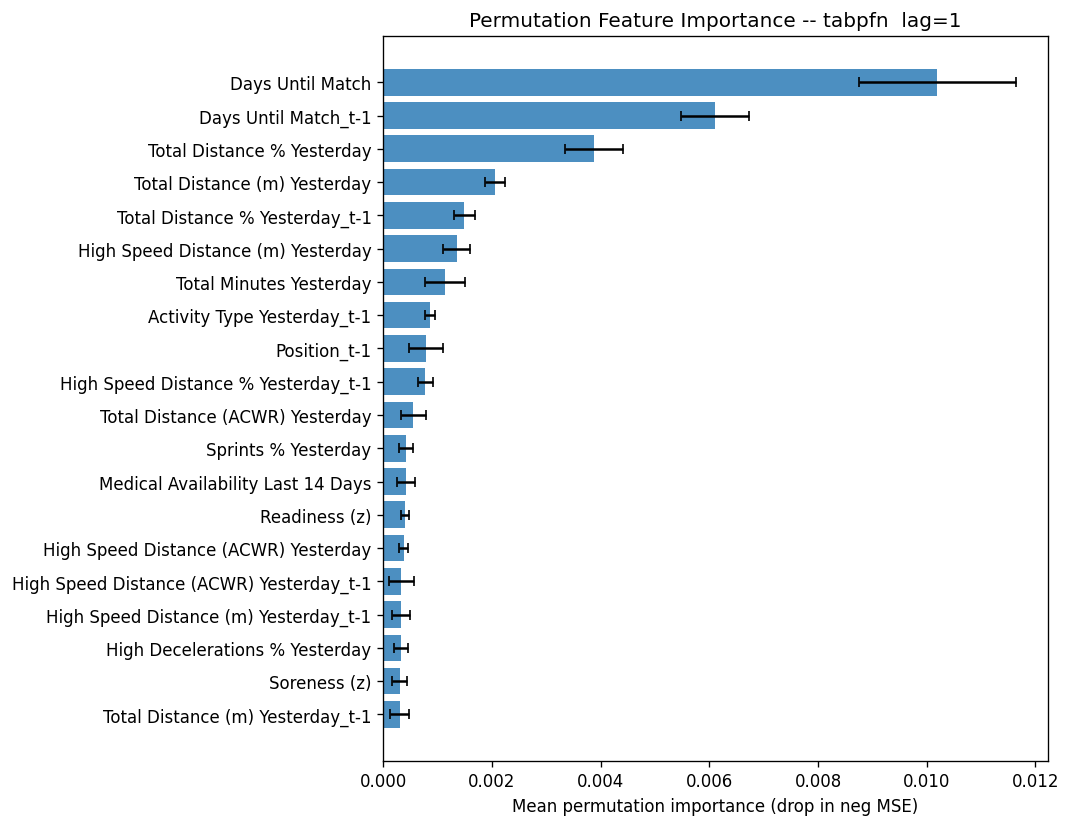

Top 10 features by permutation importance:
                            feature  importance_mean  importance_std
                   Days Until Match         0.010194        0.001450
               Days Until Match_t-1         0.006106        0.000628
         Total Distance % Yesterday         0.003876        0.000541
       Total Distance (m) Yesterday         0.002056        0.000186
     Total Distance % Yesterday_t-1         0.001493        0.000191
  High Speed Distance (m) Yesterday         0.001349        0.000243
            Total Minutes Yesterday         0.001144        0.000368
        Activity Type Yesterday_t-1         0.000856        0.000097
                       Position_t-1         0.000785        0.000320
High Speed Distance % Yesterday_t-1         0.000776        0.000133


In [20]:
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("SHAP not installed. Install with: pip install shap")

shap_res = all_results[best_model][best_lag]
trained  = shap_res.get('trained_model')
X_train  = shap_res.get('X_train')
X_test   = shap_res.get('X_test')
feature_names = shap_res.get('feature_names', [])

if trained is None or X_test is None:
    print(f"Importance analysis skipped: trained_model or X_test not available for {best_model}.")
elif best_model == 'tabpfn':
    from sklearn.inspection import permutation_importance as sklearn_perm_imp
    print(f"TabPFN detected -- using sklearn permutation importance (not SHAP).")
    print(f"Computing permutation importance (10 repeats, {X_test.shape[0]} test samples)...")
    y_test_shap = shap_res.get('y_test_true')
    perm_result = sklearn_perm_imp(trained, X_test, y_test_shap,
                                    n_repeats=10, random_state=42,
                                    scoring='neg_mean_squared_error')
    fn = feature_names if len(feature_names) == X_test.shape[1] else [f'f_{i}' for i in range(X_test.shape[1])]
    perm_df = pd.DataFrame({
        'feature': fn,
        'importance_mean': perm_result.importances_mean,
        'importance_std':  perm_result.importances_std,
    }).sort_values('importance_mean', ascending=False)
    top_n = min(20, len(perm_df))
    top = perm_df.head(top_n)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top['feature'][::-1], top['importance_mean'][::-1],
            xerr=top['importance_std'][::-1],
            color='#2c7bb6', alpha=0.85,
            error_kw=dict(ecolor='black', capsize=3))
    ax.set_xlabel('Mean permutation importance (drop in neg MSE)')
    ax.set_title(f'Permutation Feature Importance -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    print("Top 10 features by permutation importance:")
    print(perm_df.head(10).to_string(index=False))
elif shap_available:
    feature_names_shap = (list(X_test.columns)
                         if hasattr(X_test, 'columns')
                         else feature_names)
    if best_model in ('xgboost', 'catboost'):
        explainer   = shap.TreeExplainer(trained)
        shap_values = explainer.shap_values(X_test)
    else:
        explainer   = shap.LinearExplainer(trained, X_train)
        shap_values = explainer.shap_values(X_test)
    print("Beeswarm: each dot = one test observation")
    shap.summary_plot(shap_values, X_test,
                      feature_names=feature_names_shap,
                      show=False, max_display=20)
    plt.title(f'SHAP Beeswarm -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    print("Bar: mean absolute SHAP value")
    shap.summary_plot(shap_values, X_test,
                      feature_names=feature_names_shap,
                      plot_type='bar', show=False, max_display=20)
    plt.title(f'SHAP Mean |SHAP| -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    imp_vals = np.abs(shap_values).mean(axis=0)
    top_idx  = int(np.argmax(imp_vals))
    top_name = (feature_names_shap[top_idx]
                if top_idx < len(feature_names_shap) else str(top_idx))
    print(f"Dependence plot for top feature: '{top_name}'")
    shap.dependence_plot(top_idx, shap_values, X_test,
                         feature_names=feature_names_shap, show=False)
    plt.title(f'SHAP Dependence: {top_name}')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available and model is not TabPFN.")



## 8. Per-player breakdown — best model

R² and RMSE broken down per player for the best model × best lag combination.

**Red bars** (R² < 0) indicate the model performs *worse* than always predicting the training-set mean for that player — typically caused by very few test observations or a highly idiosyncratic load pattern not shared with the rest of the squad.

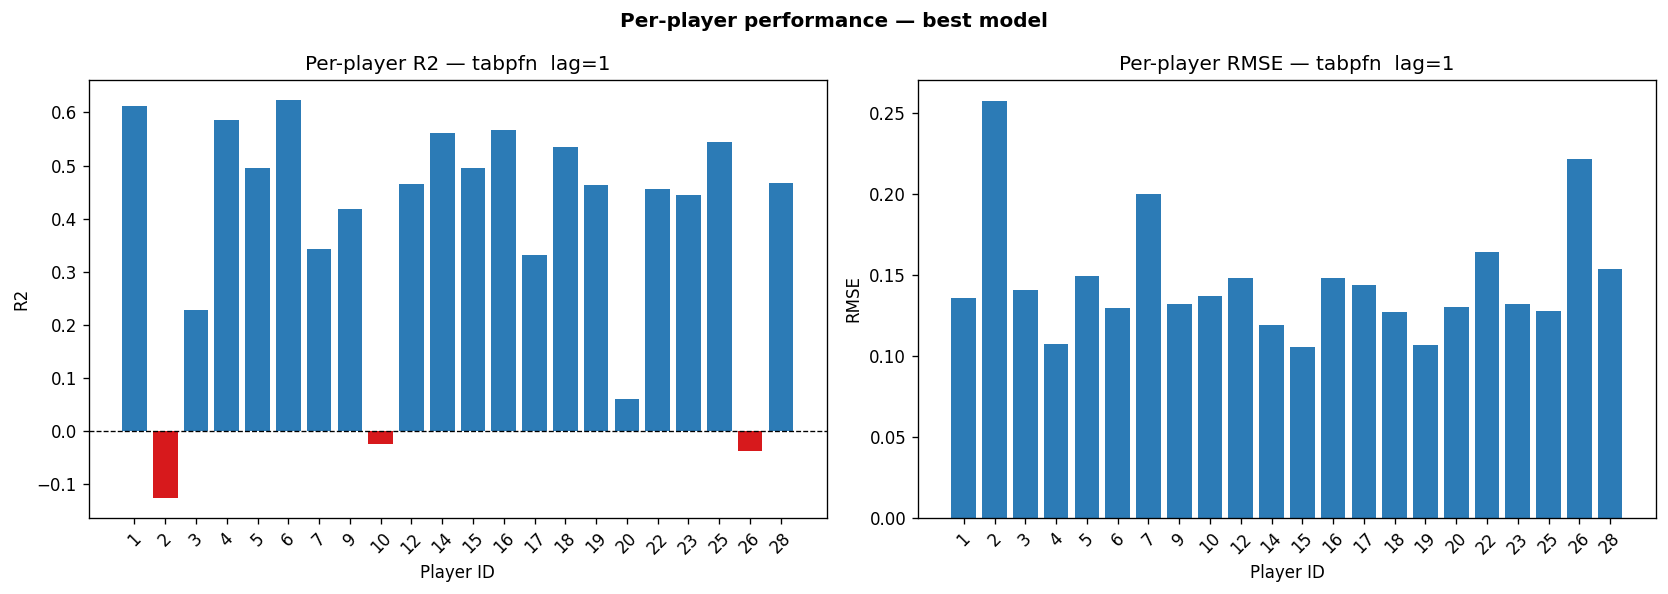


Per-player summary:
            N      RMSE        R2
Player ID                        
1          30  0.135834  0.612054
2          32  0.257249 -0.125883
3          30  0.140450  0.228066
4          30  0.107316  0.585610
5          30  0.149446  0.496225
6          30  0.129208  0.623551
7          30  0.199551  0.342220
9          31  0.132156  0.418389
10         29  0.137146 -0.023723
12         28  0.148140  0.465581
14         28  0.119049  0.560629
15         29  0.105283  0.494968
16         30  0.147750  0.566764
17         15  0.143425  0.331833
18         29  0.126807  0.535434
19         31  0.106681  0.462660
20         30  0.129821  0.059595
22         29  0.163771  0.456274
23         29  0.131753  0.443857
25         29  0.127677  0.544355
26         25  0.221201 -0.037968
28         30  0.153502  0.467599


In [21]:
# Per-player R2 and RMSE bar charts — best model x best lag
best_pp = all_results[best_model][best_lag].get('per_player', {})

if best_pp:
    pp_df = pd.DataFrame([
        {'Player ID': pid,
         'N':    v['n'],
         'RMSE': v['rmse'],
         'R2':   v['r2'] if v['r2'] is not None else float('nan')}
        for pid, v in sorted(best_pp.items())
    ]).set_index('Player ID')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # R2 bar chart
    ax = axes[0]
    colors_r2 = ['#d7191c' if r < 0 else '#2c7bb6'
                 for r in pp_df['R2'].fillna(-1)]
    ax.bar(pp_df.index.astype(str), pp_df['R2'].fillna(0), color=colors_r2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Player ID')
    ax.set_ylabel('R2')
    ax.set_title(f'Per-player R2 — {best_model}  lag={best_lag}')
    ax.tick_params(axis='x', rotation=45)

    # RMSE bar chart
    ax = axes[1]
    ax.bar(pp_df.index.astype(str), pp_df['RMSE'], color='#2c7bb6')
    ax.set_xlabel('Player ID')
    ax.set_ylabel('RMSE')
    ax.set_title(f'Per-player RMSE — {best_model}  lag={best_lag}')
    ax.tick_params(axis='x', rotation=45)

    plt.suptitle('Per-player performance — best model', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nPer-player summary:")
    print(pp_df.to_string())
else:
    print("No per-player breakdown available (meta_test may be missing).")

## 9. Summary

All experimental findings printed in plain text — scroll through the output of the next cell for the complete results report.

In [22]:
try:
    print("=" * 72)
    print("EXPERIMENT 2 — FULL FINDINGS SUMMARY")
    print("=" * 72)
    print()
    print("OBJECTIVE")
    print("-" * 40)
    print("Model the coaching staff's implicit treatment-assignment policy:")
    print("  pi(A_t | L_t) — what training intensity does the coach prescribe")
    print("  given this morning's player state?")
    print()
    print("TARGET VARIABLE: 'Training Intensity Yesterday' (target_horizon=1)")
    print("  A composite GPS score = tanh(mean(TD%, HSD%, Dec%, Sprints%) / 100)")
    print("  Range: [0, 1). 0 = full rest, ~1 = match-equivalent effort.")
    print()
    print("EXPERIMENTAL SETUP")
    print("-" * 40)
    print(f"  Models tested:        {MODELS}")
    print(f"  Lag values compared:  {LAGS}")
    print(f"  Covariates used:      {len(COVARIATES)}")
    print(f"  Test / Val split:     {TEST_SIZE} / {VAL_SIZE}")
    print()
    print("PERFORMANCE RESULTS (all model x lag combinations)")
    print("-" * 40)
    print(f"  {'Model':<12} {'Lag':>4} {'RMSE':>8} {'Null RMSE':>10} {'Skill%':>8} {'R2':>8} {'Train RMSE':>12} {'Overfit?':>10}")
    print(f"  {'-'*12} {'-'*4} {'-'*8} {'-'*10} {'-'*8} {'-'*8} {'-'*12} {'-'*10}")
    for model_type in MODELS:
        for lag in LAGS:
            m = all_results[model_type][lag]['metrics']
            skill = (1 - m['rmse'] / m['null_rmse']) * 100
            overfit = "YES" if (m['train_rmse'] < m['rmse'] * 0.7) else "no"
            print(f"  {model_type:<12} {lag:>4} {m['rmse']:>8.4f} {m['null_rmse']:>10.4f} "
                  f"{skill:>8.1f} {m['r2']:>8.4f} {m['train_rmse']:>12.4f} {overfit:>10}")
    print()
    
    best_skill = max(
        [(m, l) for m in MODELS for l in LAGS],
        key=lambda ml: (1 - all_results[ml[0]][ml[1]]['metrics']['rmse'] /
                            all_results[ml[0]][ml[1]]['metrics']['null_rmse'])
    )
    bm, bl = best_skill
    bm_res = all_results[bm][bl]
    bm_met = bm_res['metrics']
    bm_skill = (1 - bm_met['rmse'] / bm_met['null_rmse']) * 100
    
    print("OVERALL BEST MODEL")
    print("-" * 40)
    print(f"  Model:          {bm}")
    print(f"  Best lag:       {bl}")
    print(f"  Test RMSE:      {bm_met['rmse']:.4f}  (null baseline: {bm_met['null_rmse']:.4f})")
    print(f"  Skill score:    {bm_skill:+.1f}%  (reduction in RMSE vs always-predict-mean)")
    print(f"  R2:             {bm_met['r2']:.4f}")
    print(f"  Pearson r:      {bm_met['pearson_r']:.4f}  (p = {bm_met['pearson_p']:.4e})")
    print(f"  MAE:            {bm_met['mae']:.4f}")
    print(f"  Train RMSE:     {bm_met['train_rmse']:.4f}")
    print(f"  N test:         {bm_met['n_test']}")
    print()
    
    print("INTERPRETING R2 AND SKILL SCORE")
    print("-" * 40)
    if bm_met['r2'] >= 0.5:
        print("  R2 >= 0.5: The coaching policy is highly systematic and recoverable")
        print("  from observable morning-state covariates. This means:")
        print("  - Load decisions are driven primarily by physiological signals")
        print("  - The propensity model pi(A|L) will have good coverage and calibration")
        print("  - IPTW weights will have moderate variance (stable causal estimates)")
    elif bm_met['r2'] >= 0.25:
        print("  R2 in [0.25, 0.5]: Moderate systematic signal in the coaching policy.")
        print("  - A meaningful but incomplete portion of load decisions is recoverable")
        print("  - Some tactical / motivational / unobserved factors also drive decisions")
        print("  - Propensity model is still usable for IPTW but positivity may be limited")
    else:
        print("  R2 < 0.25: The coaching policy has limited systematic structure.")
        print("  - Unmeasured factors (tactical, psychological, team context) dominate")
        print("  - This does NOT invalidate the propensity model — it just means the")
        print("    model captures only a fraction of the true selection mechanism")
        print("  - IPTW weights may be extreme; trimming / stabilised weights recommended")
    print()
    
    print("LAG EFFECT ANALYSIS")
    print("-" * 40)
    for model_type in MODELS:
        rmses = [all_results[model_type][lag]['metrics']['rmse'] for lag in LAGS]
        r2s   = [all_results[model_type][lag]['metrics']['r2']   for lag in LAGS]
        best_l = LAGS[int(np.argmin(rmses))]
        rmse_improvement = (rmses[0] - min(rmses)) / rmses[0] * 100
        print(f"  {model_type:<12}  lag{LAGS[0]} RMSE={rmses[0]:.4f}  best lag={best_l} RMSE={min(rmses):.4f}  "
              f"gain={rmse_improvement:+.1f}%")
    
    all_rmses_first = [all_results[m][LAGS[0]]['metrics']['rmse'] for m in MODELS]
    all_rmses_last  = [all_results[m][LAGS[-1]]['metrics']['rmse'] for m in MODELS]
    avg_improvement = (np.mean(all_rmses_first) - np.mean(all_rmses_last)) / np.mean(all_rmses_first) * 100
    print()
    if avg_improvement > 5:
        print(f"  Average RMSE improvement lag{LAGS[0]}->lag{LAGS[-1]}: {avg_improvement:.1f}%")
        print("  => Historical load history DOES add predictive value beyond same-day state.")
        print("     The coach's load decision today is influenced by the load trend over")
        print("     the past 2-3 days, consistent with a periodisation logic.")
    else:
        print(f"  Average RMSE improvement lag{LAGS[0]}->lag{LAGS[-1]}: {avg_improvement:.1f}%")
        print("  => Adding historical lags provides minimal benefit.")
        print("     Same-day morning state captures most of the decision-relevant signal.")
    print()
    
    print("FEATURE IMPORTANCE — TOP DRIVERS OF COACHING DECISIONS")
    print("-" * 40)
    best_res = all_results[best_model][best_lag]
    weights  = best_res.get('model_weights', {})
    fnames   = best_res.get('feature_names', [])
    imps = weights.get('importances') or weights.get('feature_importances')
    if imps is None and 'coefficients' in weights:
        imps = np.abs(np.array(weights['coefficients']).flatten())
    if imps is not None and len(fnames) > 0:
        imp_arr = np.array(imps).flatten()
        imp_df  = pd.DataFrame({'feature': fnames, 'importance': imp_arr})
        imp_df  = imp_df.sort_values('importance', ascending=False).head(10)
        total   = imp_arr.sum()
        for _, row in imp_df.iterrows():
            pct = row['importance'] / total * 100 if total > 0 else 0
            print(f"  {row['feature']:<45}  {row['importance']:>8.4f}  ({pct:.1f}%)")
        print()
        top_feature = imp_df.iloc[0]['feature']
        print(f"  Most important feature: '{top_feature}'")
        if 'ACWR' in top_feature or 'Distance' in top_feature:
            print("  => Workload history (ACWR / GPS load) is the primary driver.")
            print("     Coaches modulate intensity based on recent cumulative load.")
        elif 'Fatigue' in top_feature or 'Readiness' in top_feature or 'Soreness' in top_feature:
            print("  => Wellness (fatigue / readiness / soreness) is the primary driver.")
            print("     Coaches respond to self-reported physical state when prescribing load.")
        elif 'Days' in top_feature:
            print("  => Match-cycle position (days since/until game) is the primary driver.")
            print("     Periodisation structure dominates — load is determined by where")
            print("     we are in the training week relative to the next match.")
    else:
        print("  Feature importances not available for this model type.")
    print()
    
    print("PER-PLAYER HETEROGENEITY")
    print("-" * 40)
    pp = best_res.get('per_player', {})
    if pp:
        pp_df = pd.DataFrame([
            {'Player ID': pid, 'N': v['n'], 'RMSE': v['rmse'],
             'R2': v['r2'] if v['r2'] is not None else float('nan')}
            for pid, v in sorted(pp.items())
        ])
        valid_r2 = pp_df['R2'].dropna()
        print(f"  Players in test set:  {len(pp_df)}")
        print(f"  Median R2:            {valid_r2.median():.4f}")
        print(f"  R2 range:             [{valid_r2.min():.4f}, {valid_r2.max():.4f}]")
        n_positive = (valid_r2 > 0).sum()
        n_negative = (valid_r2 <= 0).sum()
        print(f"  Players with R2 > 0:  {n_positive} ({100*n_positive/len(valid_r2):.0f}%)")
        print(f"  Players with R2 <= 0: {n_negative} (model worse than mean prediction)")
        print()
        if valid_r2.std() > 0.15:
            print("  HIGH inter-player heterogeneity detected.")
            print("  The coaching policy is well-recoverable for some players but not others.")
            print("  This could reflect: position-specific periodisation, player seniority,")
            print("  individual monitoring protocols, or injury management differences.")
        else:
            print("  LOW inter-player heterogeneity — policy recovery is consistent across")
            print("  players, suggesting a uniform team-level load management protocol.")
    print()
    
    print("PROPENSITY MODEL QUALITY — IMPLICATIONS FOR CAUSAL ANALYSIS")
    print("-" * 40)
    print(f"  The {best_model} (lag={best_lag}) model is the recommended propensity")
    print(f"  model pi(A_t | L_t) for downstream causal estimation.")
    print()
    print("  IPTW / MSM (Inverse Probability of Treatment Weighting):")
    print("    Weights: w_i = 1 / pi(A_i | L_i)")
    print("    Stabilised: w_i = p(A_i) / pi(A_i | L_i)  [reduces weight variance]")
    print(f"    Predicted range of A: use model outputs on [0, 1) training intensity scale.")
    print()
    print("  G-computation:")
    print("    Use the fitted model to predict counterfactual intensities:")
    print("    E[Y^a] = (1/n) sum_i Q(a, L_i)  where Q is the outcome model from Exp 3")
    print()
    if bm_met['r2'] > 0.3:
        print("  Overlap assessment: R2 > 0.3 suggests the model has learned the treatment")
        print("  assignment mechanism. Check propensity score distributions per player")
        print("  to confirm positivity (no extreme weights near 0 or infinity).")
    else:
        print("  Overlap concern: low R2 means predicted propensities may be near the")
        print("  unconditional mean for many observations — check ACWR violation periods")
        print("  and injured players where near-zero intensity is nearly deterministic.")
    print()
    
    print("NEXT STEPS")
    print("-" * 40)
    print("  1. Save propensity model predictions for all rows -> ps_scores.csv")
    print("  2. Inspect propensity score distributions (histograms per player)")
    print("  3. Trim extreme weights (e.g. clip at 99th percentile)")
    print("  4. Combine with Experiment 3 outcome model -> doubly-robust ATE estimate")
    print("  5. Sequential extension: Q-learning across the full match cycle (DTR)")
    print()
    print("=" * 72)
except NameError:
    print("[Summary] Run the experiment cells above first (all_results not found).")


EXPERIMENT 2 — FULL FINDINGS SUMMARY

OBJECTIVE
----------------------------------------
Model the coaching staff's implicit treatment-assignment policy:
  pi(A_t | L_t) — what training intensity does the coach prescribe
  given this morning's player state?

TARGET VARIABLE: 'Training Intensity Yesterday' (target_horizon=1)
  A composite GPS score = tanh(mean(TD%, HSD%, Dec%, Sprints%) / 100)
  Range: [0, 1). 0 = full rest, ~1 = match-equivalent effort.

EXPERIMENTAL SETUP
----------------------------------------
  Models tested:        ['lin_reg', 'xgboost', 'catboost', 'tabpfn']
  Lag values compared:  [1, 2, 3]
  Covariates used:      27
  Test / Val split:     0.2 / 0.1

PERFORMANCE RESULTS (all model x lag combinations)
----------------------------------------
  Model         Lag     RMSE  Null RMSE   Skill%       R2   Train RMSE   Overfit?
  ------------ ---- -------- ---------- -------- -------- ------------ ----------
  lin_reg         1   0.1806     0.2056     12.2   0.2042   